Árvore não otimizada
Accuracy: 0.7799819657348963
Precision: 0.7818181818181819
Recall: 0.776173285198556
F1-score: 0.7789855072463768

Resultados da validação cruzada - árvore não otimizada
   fold  accuracy  precision    recall        f1
0     1  0.801578   0.805936  0.795045  0.800454
1     2  0.792559   0.797701  0.783296  0.790433
2     3  0.786922   0.773707  0.810384  0.791621
3     4  0.803833   0.800895  0.808126  0.804494
4     5  0.766366   0.778302  0.744921  0.761246

Médias da validação cruzada - árvore não otimizada
accuracy     0.790252
precision    0.791308
recall       0.788354
f1           0.789649
dtype: float64

Desvios-padrão da validação cruzada - árvore não otimizada
accuracy     0.014998
precision    0.014368
recall       0.026613
f1           0.016944
dtype: float64
Fitting 5 folds for each of 960 candidates, totalling 4800 fits

Melhores hiperparâmetros encontrados:
{'tree__ccp_alpha': 0.0, 'tree__criterion': 'entropy', 'tree__max_depth': 3, 'tree__min_sample

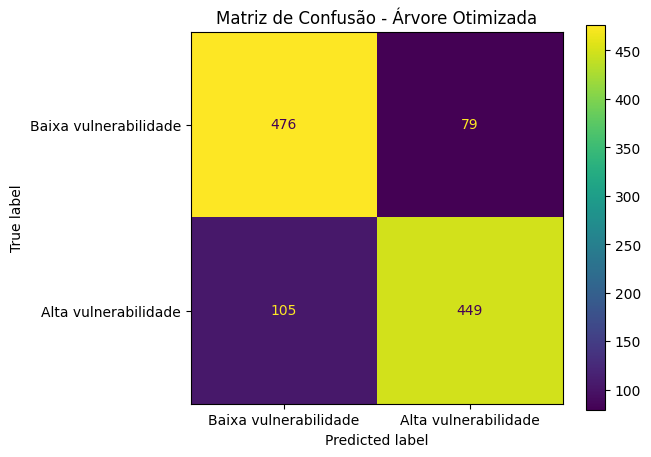


F1 por fold - melhor configuração
   fold        f1
0     1  0.853575
1     2  0.833536
2     3  0.852713
3     4  0.854007
4     5  0.841871

Média F1 por fold - melhor configuração
0.8471403830789747

Desvio-padrão F1 por fold - melhor configuração
0.009116784216344723

Comparação final no conjunto de teste
                 Modelo  Accuracy  Precision    Recall  F1-score
0  Árvore não otimizada  0.779982   0.781818  0.776173  0.778986
1      Árvore otimizada  0.834085   0.850379  0.810469  0.829945


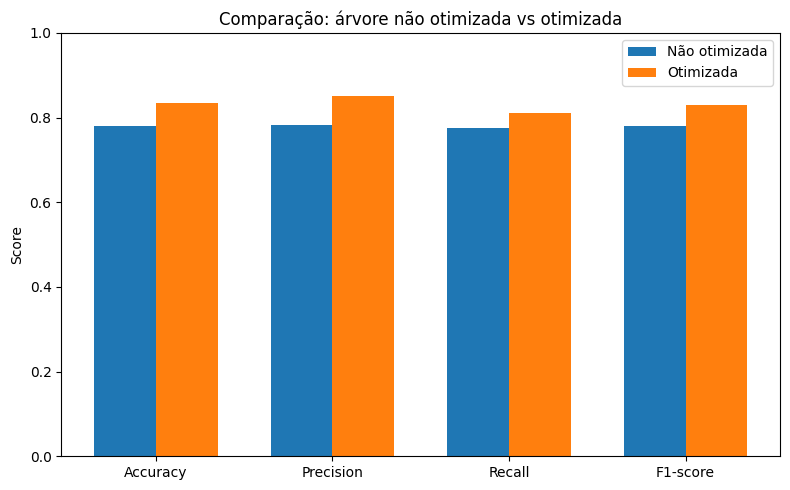

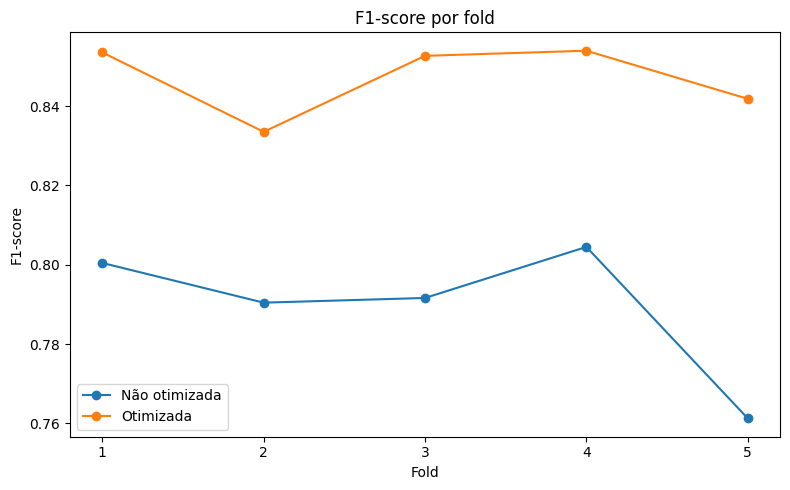


Estrutura da árvore não otimizada
Profundidade: 23
Número de folhas: 461

Estrutura da árvore otimizada
Profundidade: 3
Número de folhas: 8


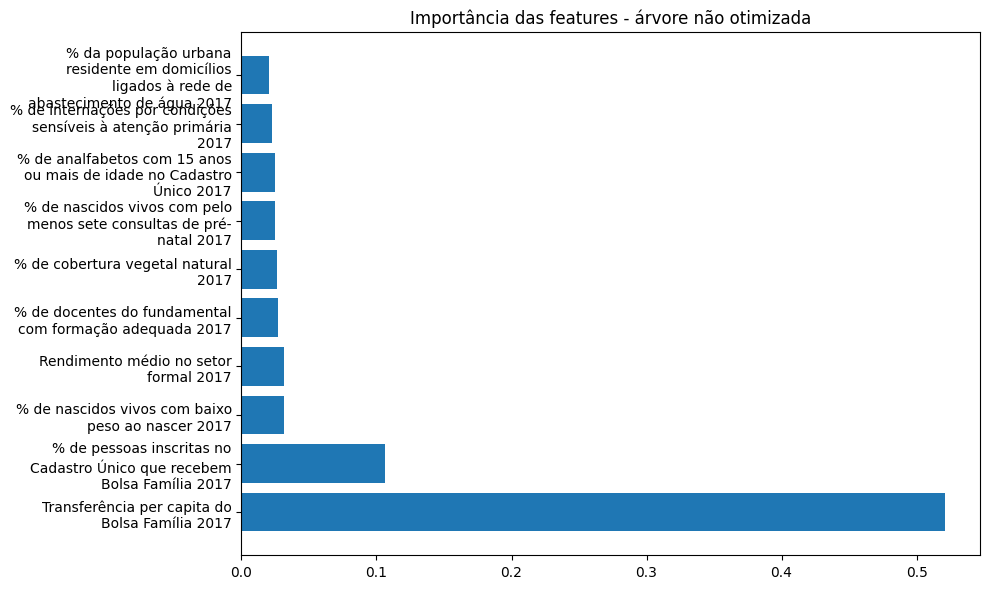

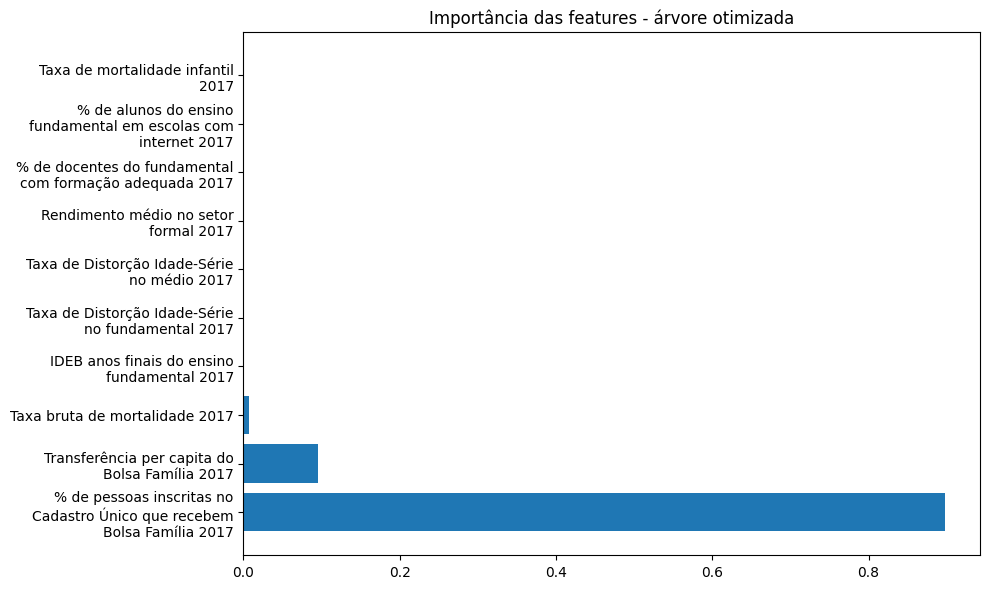

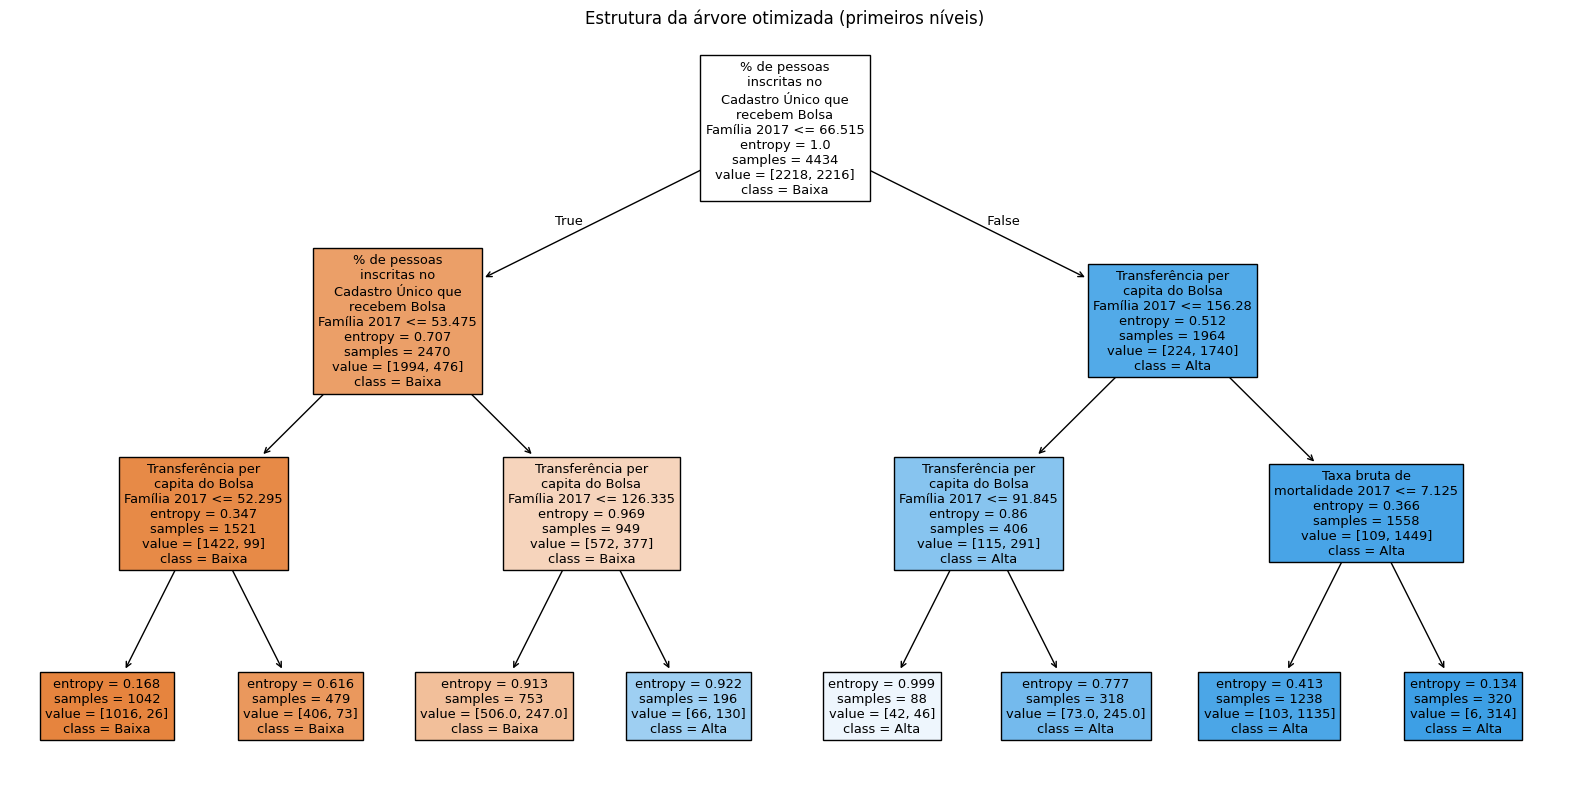


Primeiras regras da árvore otimizada:
|--- % de pessoas inscritas no Cadastro Único que recebem Bolsa Família 2017 <= 66.51
|   |--- % de pessoas inscritas no Cadastro Único que recebem Bolsa Família 2017 <= 53.48
|   |   |--- Transferência per capita do Bolsa Família 2017 <= 52.30
|   |   |   |--- class: 0
|   |   |--- Transferência per capita do Bolsa Família 2017 >  52.30
|   |   |   |--- class: 0
|   |--- % de pessoas inscritas no Cadastro Único que recebem Bolsa Família 2017 >  53.48
|   |   |--- Transferência per capita do Bolsa Família 2017 <= 126.33
|   |   |   |--- class: 0
|   |   |--- Transferência per capita do Bolsa Família 2017 >  126.33
|   |   |   |--- class: 1
|--- % de pessoas inscritas no Cadastro Único que recebem Bolsa Família 2017 >  66.51
|   |--- Transferência per capita do Bolsa Família 2017 <= 156.28
|   |   |--- Transferência per capita do Bolsa Família 2017 <= 91.85
|   |   |   |--- class: 1
|   |   |--- Transferência per capita do Bolsa Família 2017 >  91.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

CSV_PATH = '../data/censo_municipal.csv'
ID_COL = "Territorialidades"
TARGET_SOURCE_COL = "% de extremamente pobres no Cadastro Único pós Bolsa Família 2017"
TEST_SIZE = 0.20
RANDOM_STATE = 42

def wrap_labels(labels, width=30):
    return [textwrap.fill(label, width) for label in labels]

df = pd.read_csv(CSV_PATH)

for col in df.columns:
    if col != ID_COL:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace("%", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .replace(["nan", "None", ""], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[TARGET_SOURCE_COL]).copy()

threshold = df[TARGET_SOURCE_COL].median()
df["vulnerabilidade_alta"] = (df[TARGET_SOURCE_COL] > threshold).astype(int)

drop_cols = [ID_COL, TARGET_SOURCE_COL, "vulnerabilidade_alta"]

X = df.drop(columns=drop_cols).copy()
y = df["vulnerabilidade_alta"].copy()

X = X.select_dtypes(include=[np.number]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

baseline_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

baseline_tree_pipeline.fit(X_train, y_train)
baseline_pred = baseline_tree_pipeline.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_prec = precision_score(y_test, baseline_pred)
baseline_rec = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Árvore não otimizada")
print("Accuracy:", baseline_acc)
print("Precision:", baseline_prec)
print("Recall:", baseline_rec)
print("F1-score:", baseline_f1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results_baseline = cross_validate(
    baseline_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

baseline_cv_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "accuracy": cv_results_baseline["test_accuracy"],
    "precision": cv_results_baseline["test_precision"],
    "recall": cv_results_baseline["test_recall"],
    "f1": cv_results_baseline["test_f1"]
})

print("\nResultados da validação cruzada - árvore não otimizada")
print(baseline_cv_df)

print("\nMédias da validação cruzada - árvore não otimizada")
print(baseline_cv_df[["accuracy", "precision", "recall", "f1"]].mean())

print("\nDesvios-padrão da validação cruzada - árvore não otimizada")
print(baseline_cv_df[["accuracy", "precision", "recall", "f1"]].std())

param_grid = {
    "tree__criterion": ["gini", "entropy"],
    "tree__max_depth": [3, 5, 8, 10, 15, None],
    "tree__min_samples_split": [2, 5, 10, 20],
    "tree__min_samples_leaf": [1, 2, 5, 10],
    "tree__ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01]
}

grid_search = GridSearchCV(
    estimator=baseline_tree_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print("\nMelhores hiperparâmetros encontrados:")
print(best_params)

print("\nMelhor F1 médio em validação cruzada:")
print(best_cv_score)

optimized_pred = best_model.predict(X_test)

optimized_acc = accuracy_score(y_test, optimized_pred)
optimized_prec = precision_score(y_test, optimized_pred)
optimized_rec = recall_score(y_test, optimized_pred)
optimized_f1 = f1_score(y_test, optimized_pred)

print("\nÁrvore otimizada")
print("Accuracy:", optimized_acc)
print("Precision:", optimized_prec)
print("Recall:", optimized_rec)
print("F1-score:", optimized_f1)

print("\nClassification Report - árvore otimizada")
print(classification_report(y_test, optimized_pred))

cm_optimized = confusion_matrix(y_test, optimized_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["Baixa vulnerabilidade", "Alta vulnerabilidade"]
)
disp.plot(ax=plt.gca(), values_format="d")
plt.title("Matriz de Confusão - Árvore Otimizada")
plt.grid(False)
plt.show()

cv_results_df = pd.DataFrame(grid_search.cv_results_)
best_index = grid_search.best_index_

best_fold_columns = [col for col in cv_results_df.columns if col.startswith("split") and col.endswith("_test_score")]
best_fold_scores = cv_results_df.loc[best_index, best_fold_columns].values.astype(float)

optimized_cv_df = pd.DataFrame({
    "fold": np.arange(1, len(best_fold_scores) + 1),
    "f1": best_fold_scores
})

print("\nF1 por fold - melhor configuração")
print(optimized_cv_df)

print("\nMédia F1 por fold - melhor configuração")
print(optimized_cv_df["f1"].mean())

print("\nDesvio-padrão F1 por fold - melhor configuração")
print(optimized_cv_df["f1"].std())

comparison_df = pd.DataFrame({
    "Modelo": ["Árvore não otimizada", "Árvore otimizada"],
    "Accuracy": [baseline_acc, optimized_acc],
    "Precision": [baseline_prec, optimized_prec],
    "Recall": [baseline_rec, optimized_rec],
    "F1-score": [baseline_f1, optimized_f1]
})

print("\nComparação final no conjunto de teste")
print(comparison_df)

metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
baseline_metrics = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_metrics = [optimized_acc, optimized_prec, optimized_rec, optimized_f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline_metrics, width, label="Não otimizada")
plt.bar(x + width/2, optimized_metrics, width, label="Otimizada")
plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.title("Comparação: árvore não otimizada vs otimizada")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(baseline_cv_df["fold"], baseline_cv_df["f1"], marker="o", label="Não otimizada")
plt.plot(optimized_cv_df["fold"], optimized_cv_df["f1"], marker="o", label="Otimizada")
plt.xticks(np.arange(1, 6))
plt.title("F1-score por fold")
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()

baseline_tree = baseline_tree_pipeline.named_steps["tree"]
optimized_tree = best_model.named_steps["tree"]

print("\nEstrutura da árvore não otimizada")
print("Profundidade:", baseline_tree.get_depth())
print("Número de folhas:", baseline_tree.get_n_leaves())

print("\nEstrutura da árvore otimizada")
print("Profundidade:", optimized_tree.get_depth())
print("Número de folhas:", optimized_tree.get_n_leaves())

baseline_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": baseline_tree.feature_importances_
}).sort_values("importance", ascending=False).head(10)

optimized_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": optimized_tree.feature_importances_
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(wrap_labels(baseline_importances["feature"]), baseline_importances["importance"])
plt.title("Importância das features - árvore não otimizada")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(wrap_labels(optimized_importances["feature"]), optimized_importances["importance"])
plt.title("Importância das features - árvore otimizada")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    optimized_tree,
    feature_names=wrap_labels(X.columns, 20),
    class_names=["Baixa", "Alta"],
    filled=True,
    max_depth=3
)
plt.title("Estrutura da árvore otimizada (primeiros níveis)")
plt.show()

optimized_rules = export_text(optimized_tree, feature_names=list(X.columns))

print("\nPrimeiras regras da árvore otimizada:")
print(optimized_rules[:4000])